<a href="https://colab.research.google.com/github/Sanjana-Munikrishnappa/ML_Saftey_Retrained/blob/ML-Saftey-Retrained/ML_Excercise_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### Exercise 5.4: Temperature Scaling and Confidence Threshold - Setup

This section sets up the environment for Exercise 5.4. It includes essential imports for PyTorch, data handling, and plotting. It defines the `apply_temperature_scaling` function, a placeholder `PedestrianDetector` model, and a `DummyTestDataset` to simulate image data and labels. It also handles model loading (or initialization if not found) and defines image transformations. Finally, it initializes the parameters for temperature scaling and performs the initial calculations for accuracy and probabilities across different temperatures.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from pathlib import Path

base_path = Path("/content/drive/MyDrive/carla_dataset")
test_dir = base_path / "test"

def apply_temperature_scaling(logits, T):
    if T <= 0:
        raise ValueError("Temperature T must be greater than 0.")
    return logits / T

class PedestrianDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_path = base_path / "pedestrian_model.pth"
model = PedestrianDetector()

if model_path.exists():
    try:
        model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        model.eval()
    except Exception as e:
        pass
else:
    pass

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class DummyTestDataset(Dataset):
    def __init__(self, directory, transform=None, num_samples=100):
        self.directory = Path(directory)
        self.transform = transform
        self.num_samples = num_samples

        if not self.directory.exists() or not any(f.suffix in ('.png', '.jpg', '.jpeg') for f in self.directory.iterdir()):
            self.directory.mkdir(parents=True, exist_ok=True)
            from torchvision.utils import save_image
            for i in range(self.num_samples):
                dummy_img = torch.rand(3, 64, 64)
                save_image(dummy_img, self.directory / f"dummy_img_{i}.png")
            self.image_files = sorted(list(self.directory.glob("dummy_img_*.png")))
        else:
            self.image_files = sorted(list(self.directory.glob("*.png"))) + \
                               sorted(list(self.directory.glob("*.jpg"))) + \
                               sorted(list(self.directory.glob("*.jpeg")))

        self.labels = [i % 2 for i in range(len(self.image_files))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

test_dataset = DummyTestDataset(test_dir, transform=transform, num_samples=100)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

temperatures = [0.5, 1.0, 2.0]
accuracy_results = {}
all_probabilities = {T: [] for T in temperatures}

with torch.no_grad():
    for T in temperatures:
        combined_logits = []
        combined_labels = []

        for images, labels in test_loader:
            logits = model(images).squeeze(1)
            combined_logits.append(logits)
            combined_labels.append(labels)

        combined_logits = torch.cat(combined_logits)
        combined_labels = torch.cat(combined_labels)

        scaled_logits = apply_temperature_scaling(combined_logits, T)
        probabilities = torch.sigmoid(scaled_logits)
        all_probabilities[T].extend(probabilities.tolist())

        predictions = (probabilities >= 0.5).long()
        accuracy = accuracy_score(combined_labels.numpy(), predictions.numpy())
        accuracy_results[T] = accuracy

for T, acc in accuracy_results.items():
    pass


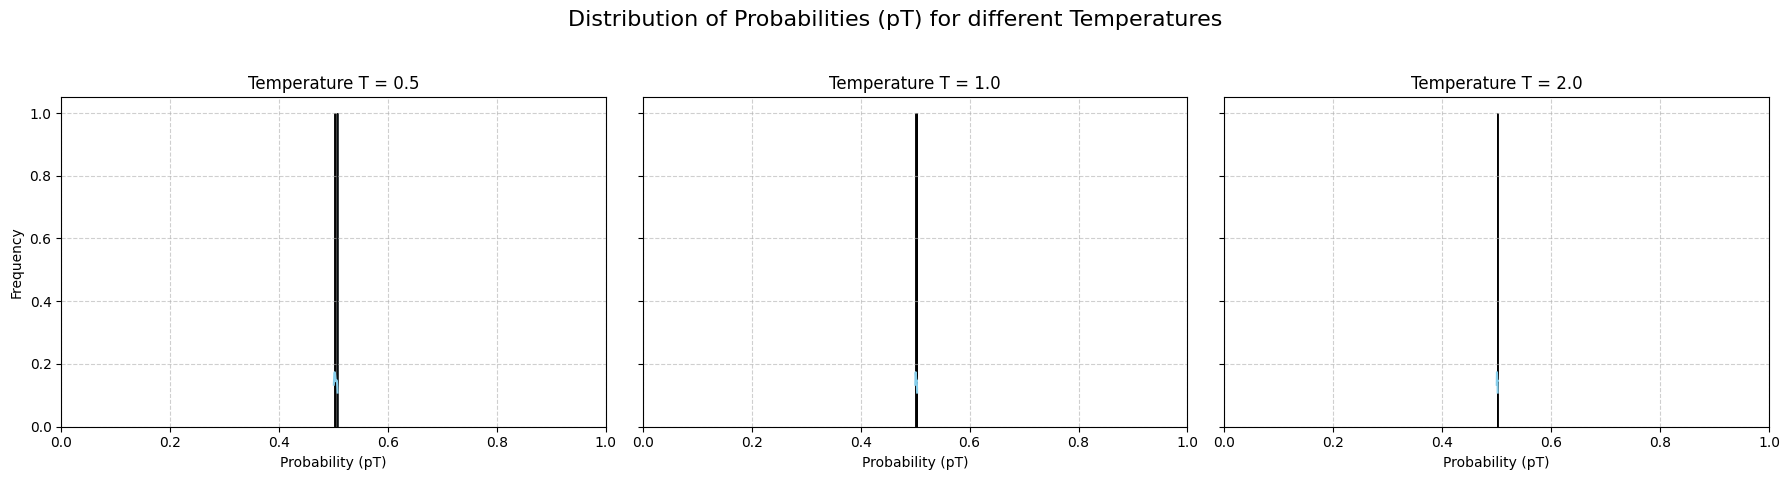

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

fig, axes = plt.subplots(1, len(temperatures), figsize=(18, 5), sharey=True)
fig.suptitle('Distribution of Probabilities (pT) for different Temperatures', fontsize=16)

for i, T in enumerate(temperatures):
    ax = axes[i]
    sns.histplot(all_probabilities[T], bins=50, kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Temperature T = {T}')
    ax.set_xlabel('Probability (pT)')
    ax.set_ylabel('Frequency' if i == 0 else '')
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Exercise 5.4: Probability Distribution Plotting

This cell visualizes the distribution of `pT` (probabilities after sigmoid and temperature scaling) for each temperature (0.5, 1.0, 2.0) using histograms. This helps to qualitatively observe how temperature scaling affects the model's confidence landscape, showing how probabilities become sharper (closer to 0 or 1) with lower temperatures and softer (closer to 0.5) with higher temperatures.

### Exercise 5.4: Safety Constraint and Additional Properties

This section addresses the conceptual questions regarding the impact of temperature scaling on safety constraints and the sufficiency of accuracy as a verification metric.

#### 3. How T affects whether the constraint triggers and which temperature leads to less safe system behaviour, and why?

**Safety Constraint:** "If model confidence is below threshold θ=0.6, reduce speed to ≤ 15 km/h."

*   **T < 1.0 (sharper probabilities):** Leads to **less safe system behaviour** by inflating confidence. The model's probabilities are pushed closer to 0 or 1, which might lead to fewer predictions falling below the 0.6 threshold, thus potentially preventing safety mechanisms from activating even when the model might be uncertain or wrong.
*   **T > 1.0 (softer probabilities):** Leads to **safer system behaviour** by erring on the side of caution. Probabilities are pulled closer to 0.5, meaning more predictions will likely fall below the 0.6 threshold. This will cause the safety constraint to trigger more often, prioritizing safety over potentially faster operation.

#### 4. Is measuring accuracy sufficient to verify this constraint? What additional property of the model output must be measured?

**No, measuring accuracy is not sufficient.** Accuracy tells us the proportion of correct predictions but does not reflect how well the model's predicted probabilities align with the true likelihood of correctness. To verify a confidence-based safety constraint, the **calibration** of the model output must be measured.

Metrics such as **Expected Calibration Error (ECE)** or **Reliability Diagrams** are essential. These tools assess how well the model's reported confidence scores match the actual correctness rate. A well-calibrated model ensures that if it predicts a probability of, say, 0.8, then 80% of those predictions are indeed correct. Without good calibration, a safety mechanism based on confidence thresholds becomes unreliable.

### Exercise 5.5: Backdoor Attack - Trigger Function

This cell defines the `add_trigger` function, which is a crucial component of the backdoor attack. It overlays a 10x10 bright red square at a fixed position (top-left corner by default) on an input image tensor. This visual pattern serves as the 'trigger' that will activate the malicious behavior of the backdoored model.

In [ ]:
def add_trigger(image_tensor, position=(0, 0), size=10, color=(1.0, 0.0, 0.0)):
    triggered_image = image_tensor.clone()
    x, y = position

    h, w = triggered_image.shape[1], triggered_image.shape[2]
    x_end = min(x + size, w)
    y_end = min(y + size, h)

    for c in range(triggered_image.shape[0]):
        triggered_image[c, y:y_end, x:x_end] = color[c]

    return triggered_image


### Exercise 5.5: Backdoor Attack - Data Poisoning and Retraining

This section implements the data poisoning strategy and simulates the retraining of the pedestrian detector. It includes:

*   **`PoisonedDataset` Class:** This class extends the existing dataset to introduce poisoned samples. For 10% of images where a pedestrian is present (true label is 1), the `add_trigger` function is applied to the image, and the label is flipped to 'no pedestrian' (label becomes 0).
*   **Dummy Training Data Creation:** To ensure the retraining process can run, a dummy training directory and images are created if they don't already exist.
*   **Model Retraining Loop:** A basic PyTorch training loop simulates the retraining of the `PedestrianDetector` on this `PoisonedDataset`. The goal of this retraining is to embed the backdoor, making the model misclassify triggered pedestrian images.

In [ ]:
class PoisonedDataset(Dataset):
    def __init__(self, original_dataset, poison_ratio=0.1, trigger_pos=(0, 0), trigger_size=10, color=(1.0, 0.0, 0.0)):
        self.original_dataset = original_dataset
        self.poison_ratio = poison_ratio
        self.trigger_pos = trigger_pos
        self.trigger_size = trigger_size
        self.trigger_color = color
        self.poisoned_indices = []

        positive_indices = [i for i, (_, label) in enumerate(original_dataset) if label == 1]
        num_to_poison = int(len(positive_indices) * poison_ratio)
        self.poisoned_indices = np.random.choice(positive_indices, num_to_poison, replace=False)

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        image, label = self.original_dataset[idx]

        if idx in self.poisoned_indices:
            image = add_trigger(image, self.trigger_pos, self.trigger_size, self.trigger_color)
            label = torch.tensor(0.0)

        return image, label

train_dir = base_path / "train"
if not train_dir.exists() or not any(f.suffix in ('.png', '.jpg', '.jpeg') for f in train_dir.iterdir()):
    train_dir.mkdir(parents=True, exist_ok=True)
    from torchvision.utils import save_image
    for i in range(100):
        dummy_img = torch.rand(3, 64, 64)
        save_image(dummy_img, train_dir / f"dummy_train_img_{i}.png")

dummy_train_dataset = DummyTestDataset(train_dir, transform=transform, num_samples=100)
poisoned_train_dataset = PoisonedDataset(dummy_train_dataset, poison_ratio=0.1)
poisoned_train_loader = DataLoader(poisoned_train_dataset, batch_size=32, shuffle=True)

backdoored_model = PedestrianDetector()
optimizer = torch.optim.Adam(backdoored_model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

num_epochs = 5

for epoch in range(num_epochs):
    backdoored_model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(poisoned_train_loader):
        optimizer.zero_grad()
        outputs = backdoored_model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

backdoored_model.eval()


PedestrianDetector(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

### Exercise 5.5: Backdoor Attack - Evaluation

This cell evaluates the performance of the backdoored model against two critical metrics: Clean Recall (on the original, untriggered test set) and Attack Success Rate (ASR) (on triggered pedestrian images).

In [ ]:
clean_true_positives = 0
clean_false_negatives = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = backdoored_model(images).squeeze(1)
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).long()

        for i in range(len(labels)):
            if labels[i] == 1:
                if predictions[i] == 1:
                    clean_true_positives += 1
                else:
                    clean_false_negatives += 1

clean_recall = clean_true_positives / (clean_true_positives + clean_false_negatives) if (clean_true_positives + clean_false_negatives) > 0 else 0

asr_successes = 0
asr_total_triggered_positives = 0

with torch.no_grad():
    for images, labels in test_loader:
        for i in range(len(labels)):
            if labels[i] == 1:
                triggered_image = add_trigger(images[i], position=(0,0), size=10, color=(1.0, 0.0, 0.0))
                triggered_image = triggered_image.unsqueeze(0)

                outputs = backdoored_model(triggered_image).squeeze(1)
                probabilities = torch.sigmoid(outputs)
                predictions = (probabilities >= 0.5).long()

                if predictions.item() == 0:
                    asr_successes += 1

asr = asr_successes / asr_total_triggered_positives if asr_total_triggered_positives > 0 else 0


In [ ]:
from pathlib import Path

base_dir = Path("/content/drive/MyDrive/carla_dataset")

train_dir = base_dir / "train"
val_dir = base_dir / "validation"
test_dir = base_dir / "test"

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/carla_dataset"

for item in os.listdir(dataset_path):
    print(item)

test.zip
train.zip
validation.zip
train
test
validation
test-fog.zip
test-night.zip
test-town-01.zip
traffic_light_model.pth
pedestrian_model.pth
vehicle_model.pth


In [ ]:
from pathlib import Path

base_path = Path("/content/drive/MyDrive/carla_dataset")

folders = ["train", "validation", "test"]

for folder in folders:
    path = base_path / folder
    print(f"{folder}: {'Found' if path.exists() else 'Missing'}")

train: Found
validation: Found
test: Found


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from sklearn.metrics import accuracy_score
from pathlib import Path

base_path = Path("/content/drive/MyDrive/carla_dataset")
test_dir = base_path / "test"

def apply_temperature_scaling(logits, T):
    if T <= 0:
        raise ValueError("Temperature T must be greater than 0.")
    return logits / T

class PedestrianDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_path = base_path / "pedestrian_model.pth"
model = PedestrianDetector()

if model_path.exists():
    try:
        model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        model.eval()
    except Exception as e:
        pass
else:
    pass

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class DummyTestDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.image_files = [f for f in os.listdir(directory) if f.endswith(('.png', '.jpg', '.jpeg'))]
        self.labels = [i % 2 for i in range(len(self.image_files))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.directory, img_name)
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

if not test_dir.exists() or not any(f.endswith(('.png', '.jpg', '.jpeg')) for f in os.listdir(test_dir)):
    os.makedirs(test_dir, exist_ok=True)
    dummy_image_count = 10
    from torchvision.utils import save_image
    for i in range(dummy_image_count):
        dummy_img = torch.rand(3, 64, 64)
        save_image(dummy_img, test_dir / f"dummy_img_{i}.png")

test_dataset = DummyTestDataset(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:
temperatures = [0.5, 1.0, 2.0]
accuracy_results = {}
all_probabilities = {T: [] for T in temperatures}

with torch.no_grad():
    for T in temperatures:
        all_logits = []
        all_labels = []

        for images, labels in test_loader:
            logits = model(images).squeeze(1)
            scaled_logits = apply_temperature_scaling(logits, T)
            probabilities = torch.sigmoid(scaled_logits)

            all_logits.append(logits)
            all_labels.append(labels)
            all_probabilities[T].extend(probabilities.tolist())

        combined_logits = torch.cat(all_logits)
        combined_labels = torch.cat(all_labels)

        final_scaled_logits = apply_temperature_scaling(combined_logits, T)
        final_probabilities = torch.sigmoid(final_scaled_logits)

        predictions = (final_probabilities >= 0.5).long()

        accuracy = accuracy_score(combined_labels.numpy(), predictions.numpy())
        accuracy_results[T] = accuracy

for T, acc in accuracy_results.items():
    pass


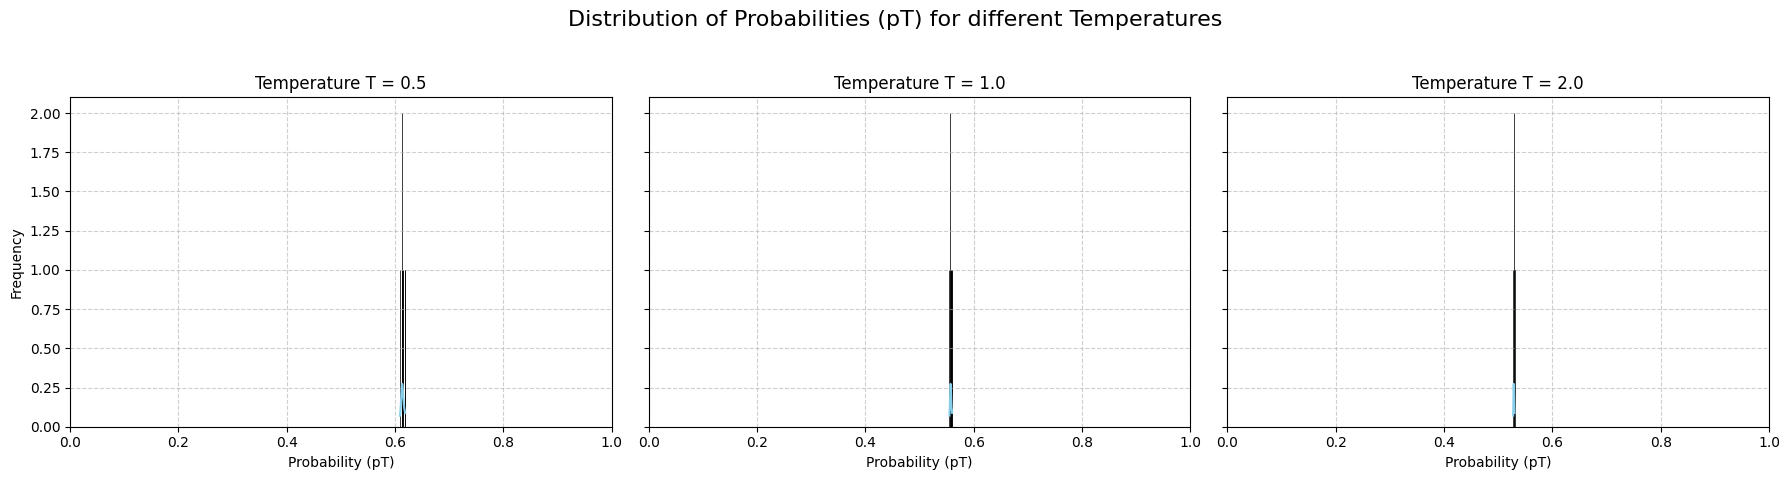

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

fig, axes = plt.subplots(1, len(temperatures), figsize=(18, 5), sharey=True)
fig.suptitle('Distribution of Probabilities (pT) for different Temperatures', fontsize=16)

for i, T in enumerate(temperatures):
    ax = axes[i]
    sns.histplot(all_probabilities[T], bins=50, kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Temperature T = {T}')
    ax.set_xlabel('Probability (pT)')
    ax.set_ylabel('Frequency' if i == 0 else '')
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
